#Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import xgboost as xgb
from sklearn.metrics import confusion_matrix, classification_report
from collections import Counter
import matplotlib.pyplot as plt
from xgboost import plot_importance
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import pickle
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix
from tensorflow.keras.layers import BatchNormalization, LeakyReLU
from tensorflow.keras.optimizers import Adam
import yfinance as yf
from google.colab import drive
import os
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, SimpleRNN, Dropout
import os
from tensorflow.keras.models import load_model
from sklearn.metrics import mean_absolute_error

#Data Arrangement

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
df = pd.read_csv('/content/drive/MyDrive/1פרויקט גמר/sp500_daily.csv')
df

,Price,Close,High,Low,Open,Volume
0,Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
1,Date,NaN,NaN,NaN,NaN,NaN
2,2020-01-02,3257.85009765625,3258.139892578125,3235.530029296875,3244.669921875,3459930000
3,2020-01-03,3234.85009765625,3246.14990234375,3222.340087890625,3226.360107421875,3484700000
4,2020-01-06,3246.280029296875,3246.840087890625,3214.639892578125,3217.550048828125,3702460000
...,...,...,...,...,...,...
1516,2026-01-12,6977.27001953125,6986.330078125,6934.06982421875,6944.1201171875,5019040000
1517,2026-01-13,6963.740234375,6985.830078125,6938.77001953125,6977.41015625,5091730000
1518,2026-01-14,6926.60009765625,6941.2998046875,6885.740234375,6937.41015625,5530830000
1519,2026-01-15,6944.47021484375,6979.33984375,6937.93017578125,6969.4599609375,5114050000


In [4]:
df.isna().any(axis=1).sum()

np.int64(1)

In [5]:
df = df.dropna()


In [6]:
df = df.drop(index=0).reset_index(drop=True)

In [7]:
df['Open_tomorrow'] = df['Open'].shift(-1)

In [8]:
df['Open_gt_Close'] = (df['Open_tomorrow'] > df['Close']).astype(int)

In [9]:
df['Close_gt_Open'] = (df['Close'] > df['Close'].shift(1)).astype(int)

In [10]:
df = df.dropna(subset=['Open_tomorrow'])

In [11]:
df

,Price,Close,High,Low,Open,Volume,Open_tomorrow,Open_gt_Close,Close_gt_Open
0,2020-01-02,3257.85009765625,3258.139892578125,3235.530029296875,3244.669921875,3459930000,3226.360107421875,0,0
1,2020-01-03,3234.85009765625,3246.14990234375,3222.340087890625,3226.360107421875,3484700000,3217.550048828125,0,0
2,2020-01-06,3246.280029296875,3246.840087890625,3214.639892578125,3217.550048828125,3702460000,3241.860107421875,0,1
3,2020-01-07,3237.179931640625,3244.909912109375,3232.429931640625,3241.860107421875,3435910000,3238.590087890625,1,0
4,2020-01-08,3253.050048828125,3267.070068359375,3236.669921875,3238.590087890625,3726840000,3266.030029296875,1,1
...,...,...,...,...,...,...,...,...,...
1513,2026-01-09,6966.27978515625,6978.35986328125,6917.64013671875,6927.830078125,5163900000,6944.1201171875,0,1
1514,2026-01-12,6977.27001953125,6986.330078125,6934.06982421875,6944.1201171875,5019040000,6977.41015625,1,1
1515,2026-01-13,6963.740234375,6985.830078125,6938.77001953125,6977.41015625,5091730000,6937.41015625,0,0
1516,2026-01-14,6926.60009765625,6941.2998046875,6885.740234375,6937.41015625,5530830000,6969.4599609375,1,0


In [12]:
df['Close_tomorrow'] = df['Close'].shift(-1)


In [13]:
df

,Price,Close,High,Low,Open,Volume,Open_tomorrow,Open_gt_Close,Close_gt_Open,Close_tomorrow
0,2020-01-02,3257.85009765625,3258.139892578125,3235.530029296875,3244.669921875,3459930000,3226.360107421875,0,0,3234.85009765625
1,2020-01-03,3234.85009765625,3246.14990234375,3222.340087890625,3226.360107421875,3484700000,3217.550048828125,0,0,3246.280029296875
2,2020-01-06,3246.280029296875,3246.840087890625,3214.639892578125,3217.550048828125,3702460000,3241.860107421875,0,1,3237.179931640625
3,2020-01-07,3237.179931640625,3244.909912109375,3232.429931640625,3241.860107421875,3435910000,3238.590087890625,1,0,3253.050048828125
4,2020-01-08,3253.050048828125,3267.070068359375,3236.669921875,3238.590087890625,3726840000,3266.030029296875,1,1,3274.699951171875
...,...,...,...,...,...,...,...,...,...,...
1513,2026-01-09,6966.27978515625,6978.35986328125,6917.64013671875,6927.830078125,5163900000,6944.1201171875,0,1,6977.27001953125
1514,2026-01-12,6977.27001953125,6986.330078125,6934.06982421875,6944.1201171875,5019040000,6977.41015625,1,1,6963.740234375
1515,2026-01-13,6963.740234375,6985.830078125,6938.77001953125,6977.41015625,5091730000,6937.41015625,0,0,6926.60009765625
1516,2026-01-14,6926.60009765625,6941.2998046875,6885.740234375,6937.41015625,5530830000,6969.4599609375,1,0,6944.47021484375


#אימון 1

In [14]:
k_days=20
test_size = 0.3
features = ["Open","Volume"]
target = 'Close_gt_Open'

In [15]:
X = pd.concat([df[features].shift(i) for i in reversed(range(k_days))], axis=1)
X.columns = [f"{feat}_t-{i}" for i in reversed(range(k_days)) for feat in features]
y = df[target]

In [16]:
X = X.iloc[k_days-1:].reset_index(drop=True)
y = y.iloc[k_days-1:].reset_index(drop=True)

In [17]:
X_np = X.to_numpy().astype(float)
y_np = y.to_numpy().astype(int)

In [18]:
split_idx = int(len(X_np) * (1 - test_size))
X_train, X_test = X_np[:split_idx], X_np[split_idx:]
y_train, y_test = y_np[:split_idx], y_np[split_idx:]

In [19]:
counter = Counter(y_train)
weight = counter[0] / counter[1]
model = xgb.XGBClassifier(
    scale_pos_weight=weight,
    n_estimators=350,
    max_depth=6,
    learning_rate=0.02,
    # use_label_encoder=False,
     eval_metric='logloss'

)
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.02, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=350, n_jobs=None,
              num_parallel_tree=None, ...)

In [20]:
y_pred = model.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.45      0.54      0.49       190
           1       0.60      0.51      0.55       260

    accuracy                           0.52       450
   macro avg       0.52      0.52      0.52       450
weighted avg       0.54      0.52      0.53       450



In [21]:
k_days = 20 # מספר הימים אחורה שאת בודקת

feature_names = []

# יצירת השמות עבור המערך
for col in features:
    feature_names.append(f"{col}_current") # הערך של היום
    for i in range(1, k_days ):
        feature_names.append(f"{col}_lag_{i}") # הערכים של ימי העבר
print(feature_names)

['Open_current', 'Open_lag_1', 'Open_lag_2', 'Open_lag_3', 'Open_lag_4', 'Open_lag_5', 'Open_lag_6', 'Open_lag_7', 'Open_lag_8', 'Open_lag_9', 'Open_lag_10', 'Open_lag_11', 'Open_lag_12', 'Open_lag_13', 'Open_lag_14', 'Open_lag_15', 'Open_lag_16', 'Open_lag_17', 'Open_lag_18', 'Open_lag_19', 'Volume_current', 'Volume_lag_1', 'Volume_lag_2', 'Volume_lag_3', 'Volume_lag_4', 'Volume_lag_5', 'Volume_lag_6', 'Volume_lag_7', 'Volume_lag_8', 'Volume_lag_9', 'Volume_lag_10', 'Volume_lag_11', 'Volume_lag_12', 'Volume_lag_13', 'Volume_lag_14', 'Volume_lag_15', 'Volume_lag_16', 'Volume_lag_17', 'Volume_lag_18', 'Volume_lag_19']


40


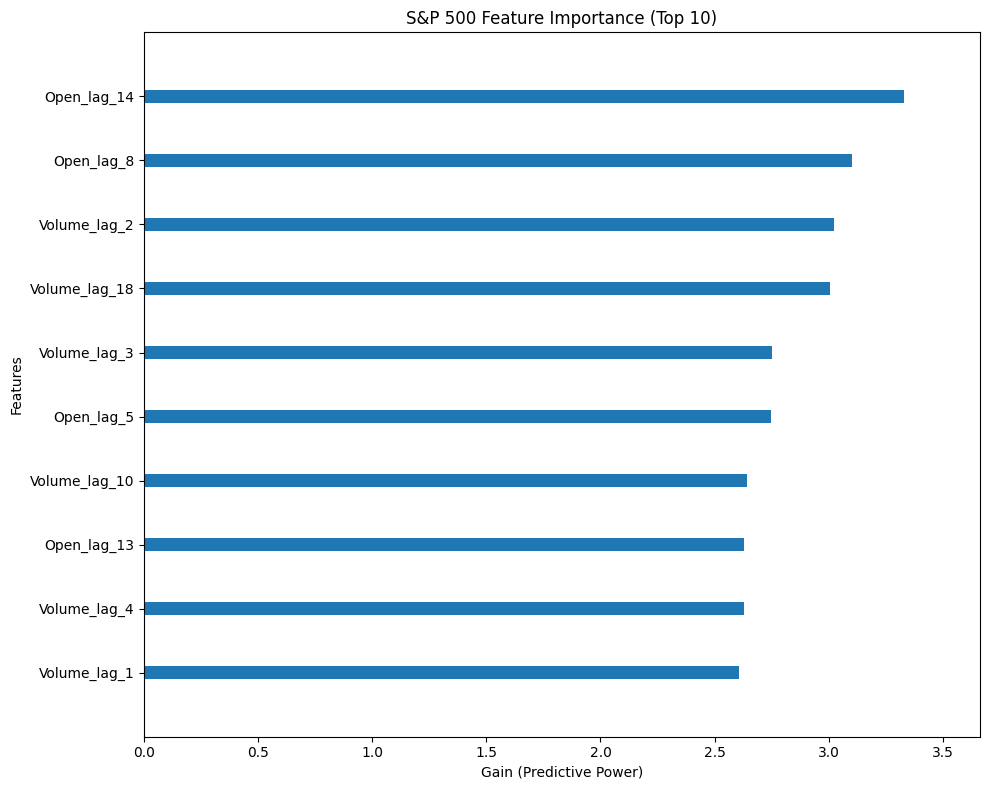

In [22]:

# X_train was sliced twice by [:,:-1], so remove the last two feature names
corrected_feature_names = feature_names
print (len(corrected_feature_names))
model.get_booster().feature_names = corrected_feature_names

# 2. הגדרת גודל הגרף (כדי שיהיה מקום לשמות ארוכים בצד)
plt.rcParams["figure.figsize"] = (10, 8)

# 3. יצירת גרף הבארים (Feature Importance)
# הערה: העברנו את ה-importance_type ל-'gain' כי הוא משמעותי יותר בחיזוי מניות
plot_importance(model,
                max_num_features=10, # נציג את ה-10 הכי חזקים מתוך הרשימה
                importance_type='gain',
                grid=False,
                show_values=False, # כדי שהגרף יהיה נקי
                title='S&P 500 Feature Importance (Top 10)',
                xlabel='Gain (Predictive Power)',
                ylabel='Features')

plt.tight_layout() # מבטיח שהשמות לא ייחתכו בשוליים
plt.show()
# k_days=13
# test_size = 0.2
# features = ["Volume","Open","High",]
# target = 'Close_gt_Open'

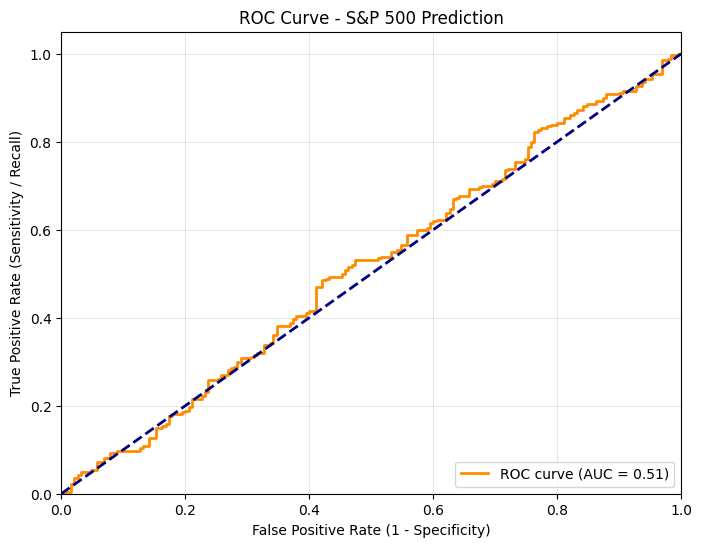

In [23]:

# 1. קבלת ההסתברויות מהמודל (הסתברות למחלקה 1 - עלייה)
y_probs = model.predict_proba(X_test)[:, 1]

# 2. חישוב נתוני ה-ROC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_value = roc_auc_score(y_test, y_probs)

# 3. ציור הגרף
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_value:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # קו האלכסון (רנדומלי)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity / Recall)')
plt.title('ROC Curve - S&P 500 Prediction')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()
# k_days=13
# test_size = 0.2
# features = ["Volume","Open","High",]
# target = 'Close_gt_Open'

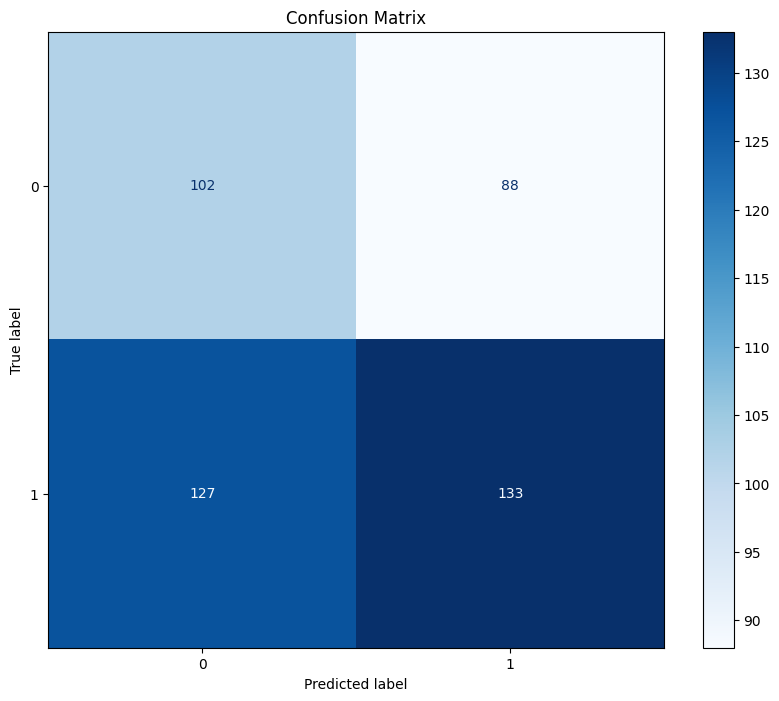

In [24]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()
# k_days=13
# test_size = 0.2
# features = ["Volume","Open","High",]
# target = 'Close_gt_Open'

In [25]:
print(X_test.shape,y_test.shape)

(450, 40) (450,)


In [26]:
print(X_train.shape,y_train.shape)

(1049, 40) (1049,)


#אימון2

In [ ]:
k_days=9
test_size = 0.3
features = ["Volume","Open","High"]
target = 'Open_gt_Close'

In [ ]:
X = pd.concat([df[features].shift(i) for i in reversed(range(k_days))], axis=1)
X.columns = [f"{feat}_t-{i}" for i in reversed(range(k_days)) for feat in features]
y = df[target]

In [ ]:
X = X.iloc[k_days-1:].reset_index(drop=True)
y = y.iloc[k_days-1:].reset_index(drop=True)

In [ ]:
X_np = X.to_numpy().astype(float)
y_np = y.to_numpy().astype(int)

In [ ]:
split_idx = int(len(X_np) * (1 - test_size))
X_train, X_test = X_np[:split_idx], X_np[split_idx:]
y_train, y_test = y_np[:split_idx], y_np[split_idx:]

In [ ]:
counter = Counter(y_train)
weight = counter[0] / counter[1]
model = xgb.XGBClassifier(
    scale_pos_weight=weight,
    n_estimators=250,
    max_depth=6,
    learning_rate=0.02,
    # use_label_encoder=False,
     eval_metric='logloss'

)
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.02, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=250, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_pred = model.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.39      0.36      0.37       173
           1       0.62      0.65      0.64       280

    accuracy                           0.54       453
   macro avg       0.50      0.50      0.50       453
weighted avg       0.53      0.54      0.53       453



In [ ]:
k_days = 9 # מספר הימים אחורה שאת בודקת

feature_names = []

# יצירת השמות עבור המערך
for col in features:
    feature_names.append(f"{col}_current") # הערך של היום
    for i in range(1, k_days ):
        feature_names.append(f"{col}_lag_{i}") # הערכים של ימי העבר
print(feature_names)

['Volume_current', 'Volume_lag_1', 'Volume_lag_2', 'Volume_lag_3', 'Volume_lag_4', 'Volume_lag_5', 'Volume_lag_6', 'Volume_lag_7', 'Volume_lag_8', 'Open_current', 'Open_lag_1', 'Open_lag_2', 'Open_lag_3', 'Open_lag_4', 'Open_lag_5', 'Open_lag_6', 'Open_lag_7', 'Open_lag_8', 'High_current', 'High_lag_1', 'High_lag_2', 'High_lag_3', 'High_lag_4', 'High_lag_5', 'High_lag_6', 'High_lag_7', 'High_lag_8']


27


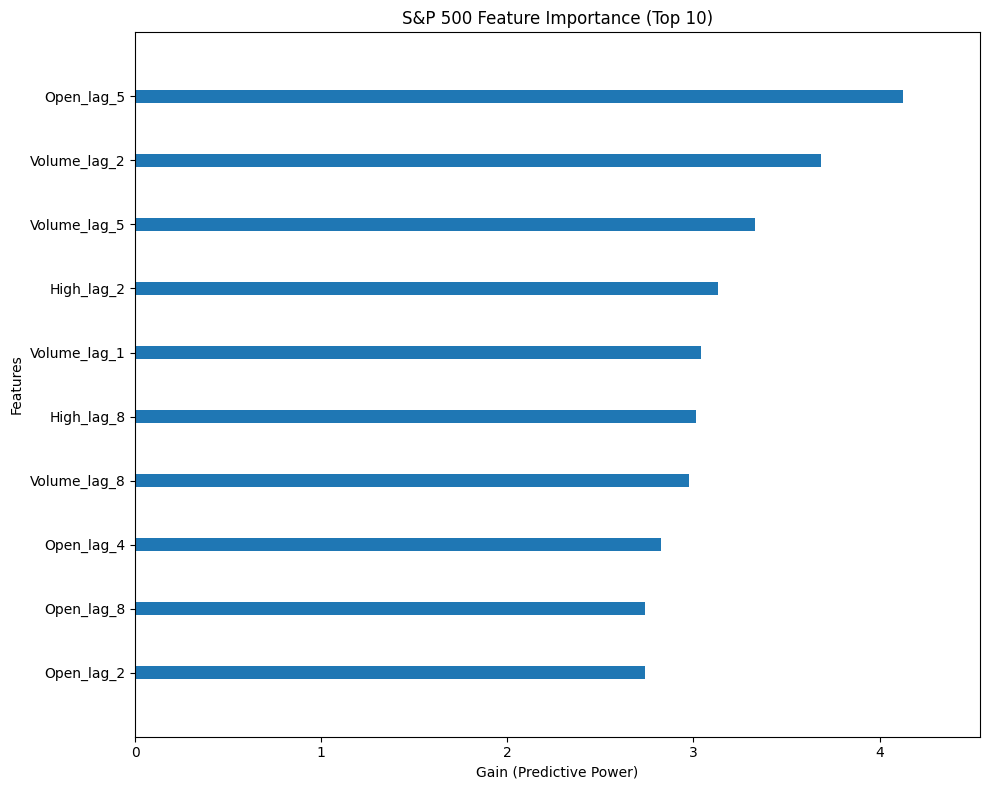

In [ ]:
corrected_feature_names = feature_names
print (len(corrected_feature_names))
model.get_booster().feature_names = corrected_feature_names

# 2. הגדרת גודל הגרף (כדי שיהיה מקום לשמות ארוכים בצד)
plt.rcParams["figure.figsize"] = (10, 8)

# 3. יצירת גרף הבארים (Feature Importance)
# הערה: העברנו את ה-importance_type ל-'gain' כי הוא משמעותי יותר בחיזוי מניות
plot_importance(model,
                max_num_features=10, # נציג את ה-10 הכי חזקים מתוך הרשימה
                importance_type='gain',
                grid=False,
                show_values=False, # כדי שהגרף יהיה נקי
                title='S&P 500 Feature Importance (Top 10)',
                xlabel='Gain (Predictive Power)',
                ylabel='Features')

plt.tight_layout() # מבטיח שהשמות לא ייחתכו בשוליים
plt.show()

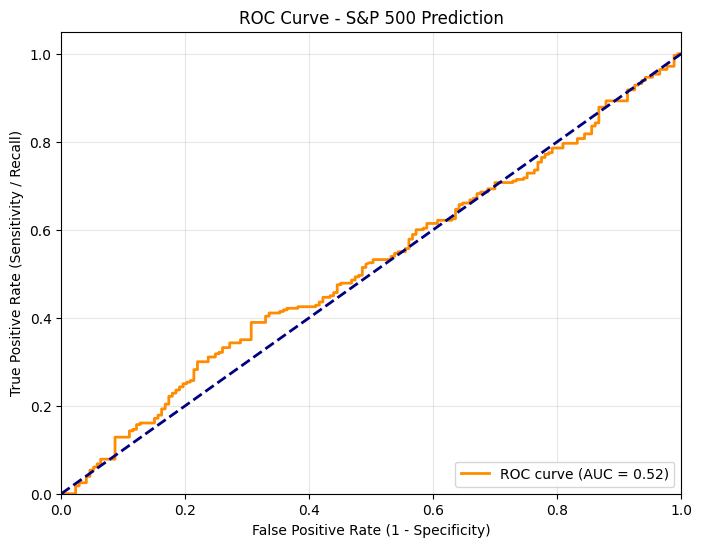

In [ ]:
# k_days=9
# test_size = 0.3
# features = ["Volume","Open","High"]
# target = 'Close_gt_Open'
y_probs = model.predict_proba(X_test)[:, 1]

# 2. חישוב נתוני ה-ROC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_value = roc_auc_score(y_test, y_probs)

# 3. ציור הגרף
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_value:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # קו האלכסון (רנדומלי)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity / Recall)')
plt.title('ROC Curve - S&P 500 Prediction')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

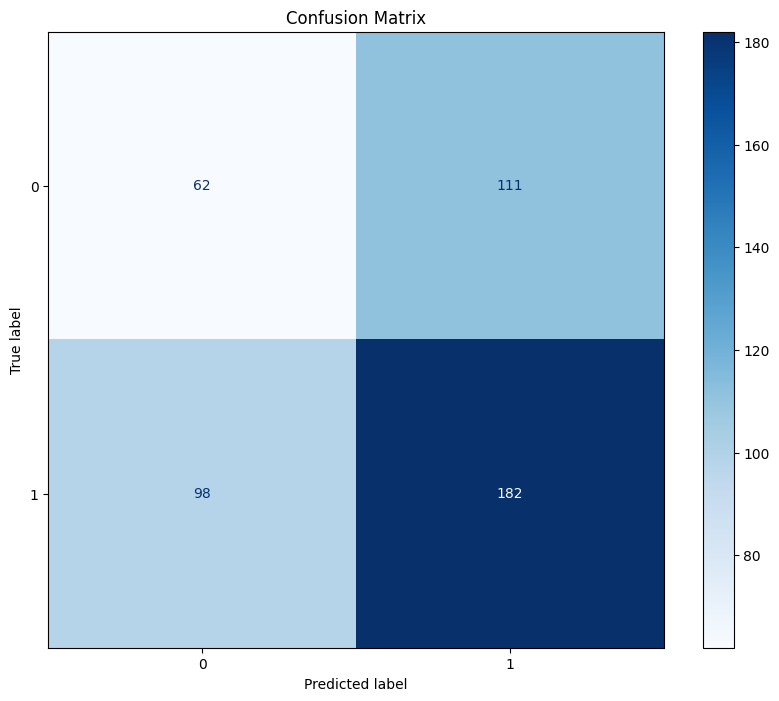

In [ ]:
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()
# k_days=9
# test_size = 0.3
# features = ["Volume","Open","High"]
# target = 'Close_gt_Open'

#אימון3


In [ ]:
k_days=13
test_size = 0.3
features = ["Volume","Open","High","Open_gt_Close"]
target = 'Close_gt_Open'

In [ ]:
X = pd.concat([df[features].shift(i) for i in reversed(range(k_days))], axis=1)
X.columns = [f"{feat}_t-{i}" for i in reversed(range(k_days)) for feat in features]
y = df[target]

In [ ]:
X = pd.concat([df[features].shift(i) for i in reversed(range(k_days))], axis=1)
X.columns = [f"{feat}_t-{i}" for i in reversed(range(k_days)) for feat in features]
y = df[target]

In [ ]:
X_np = X.to_numpy().astype(float)
y_np = y.to_numpy().astype(int)

In [ ]:
split_idx = int(len(X_np) * (1 - test_size))
X_train, X_test = X_np[:split_idx], X_np[split_idx:]
y_train, y_test = y_np[:split_idx], y_np[split_idx:]

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

X_train = X_train[:, :-1]
X_val = X_val[:, :-1]

counter = Counter(y_train)
weight = counter[0] / counter[1]

model = xgb.XGBClassifier(
    scale_pos_weight=weight,
    n_estimators=450,
    max_depth=6,
    learning_rate=0.02,
    eval_metric='logloss',
    early_stopping_rounds=10
)
model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=True
)

[0]	validation_0-logloss:0.68900
[1]	validation_0-logloss:0.68509
[2]	validation_0-logloss:0.68136
[3]	validation_0-logloss:0.67771
[4]	validation_0-logloss:0.67421
[5]	validation_0-logloss:0.67109
[6]	validation_0-logloss:0.66800
[7]	validation_0-logloss:0.66539
[8]	validation_0-logloss:0.66285
[9]	validation_0-logloss:0.65984
[10]	validation_0-logloss:0.65721
[11]	validation_0-logloss:0.65452
[12]	validation_0-logloss:0.65215
[13]	validation_0-logloss:0.64994
[14]	validation_0-logloss:0.64762
[15]	validation_0-logloss:0.64640
[16]	validation_0-logloss:0.64421
[17]	validation_0-logloss:0.64217
[18]	validation_0-logloss:0.64063
[19]	validation_0-logloss:0.63932
[20]	validation_0-logloss:0.63727
[21]	validation_0-logloss:0.63475
[22]	validation_0-logloss:0.63278
[23]	validation_0-logloss:0.63130
[24]	validation_0-logloss:0.63001
[25]	validation_0-logloss:0.62836
[26]	validation_0-logloss:0.62705
[27]	validation_0-logloss:0.62570
[28]	validation_0-logloss:0.62466
[29]	validation_0-loglos

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=10,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.02, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=450, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, f1_score

# Re-create X_test from the original X_np to ensure correct number of features.
# X_np and split_idx are available from previous cells.
X_test_original_features = X_np[split_idx:]
X_test_for_prediction = X_test_original_features[:, :-1] # Slice once to get 51 features

y_pred=model.predict(X_test_for_prediction)
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1 Score:  {f1:.4f}")

Confusion Matrix:
[[112  82]
 [ 78 184]]
Accuracy: 0.6491
Precision: 0.6917
F1 Score:  0.6970


In [ ]:
model.get_booster().feature_names = features

51


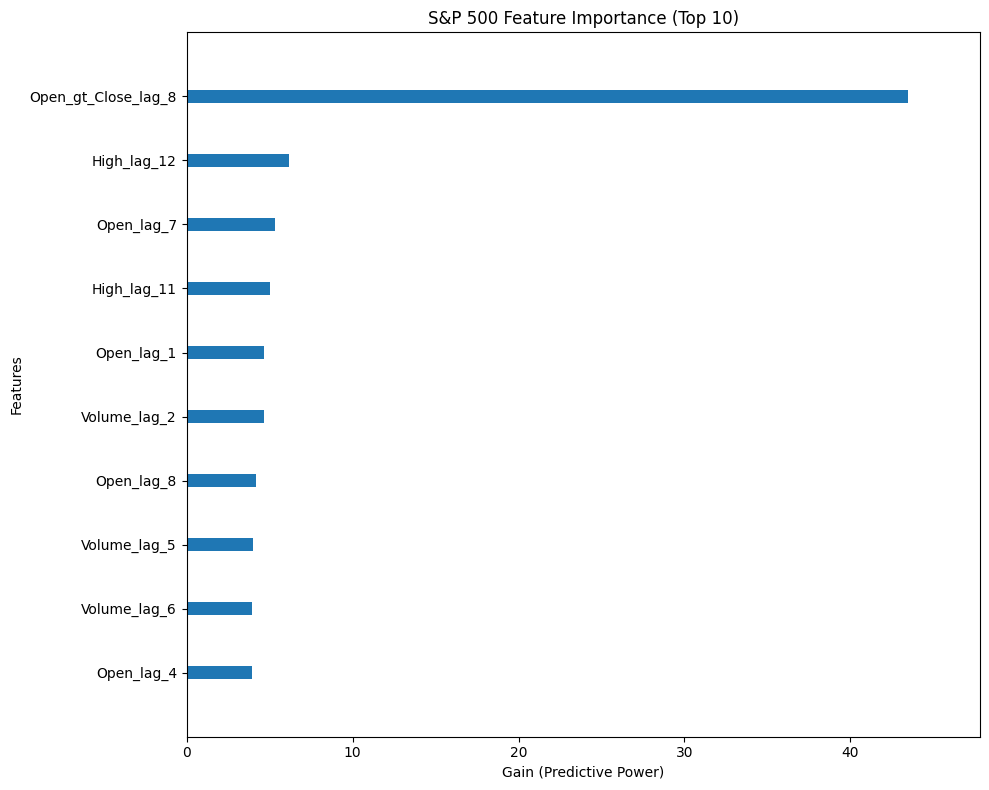

In [ ]:
k_days = 13 # This needs to be defined for the feature_names generation
features = ["Volume","Open","High","Open_gt_Close"] # This needs to be defined for the feature_names generation

feature_names = []

# יצירת השמות עבור המערך
for col in features:
    feature_names.append(f"{col}_current") # הערך של היום
    for i in range(1, k_days ):
        feature_names.append(f"{col}_lag_{i}") # הערכים של ימי העבר

corrected_feature_names = feature_names[:-1] # This is consistent with X_train and X_val[:, :-1]
print (len(corrected_feature_names))
model.get_booster().feature_names = corrected_feature_names

# 2. הגדרת גודל הגרף (כדי שיהיה מקום לשמות ארוכים בצד)
plt.rcParams["figure.figsize"] = (10, 8)

# 3. יצירת גרף הבארים (Feature Importance)
# הערה: העברנו את ה-importance_type ל-'gain' כי הוא משמעותי יותר בחיזוי מניות
plot_importance(model,
                max_num_features=10, # נציג את ה-10 הכי חזקים מתוך הרשימה
                importance_type='gain',
                grid=False,
                show_values=False, # כדי שהגרף יהיה נקי
                title='S&P 500 Feature Importance (Top 10)',
                xlabel='Gain (Predictive Power)',
                ylabel='Features')

plt.tight_layout() # מבטיח שהשמות לא ייחתכו בשוליים
plt.show()

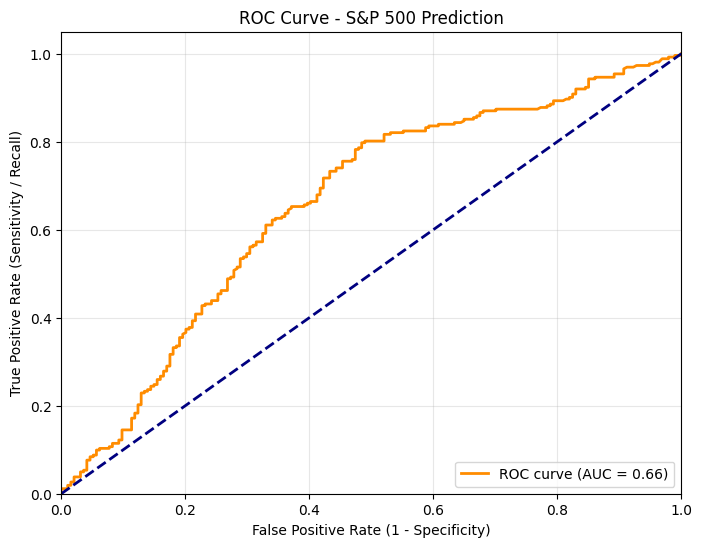

In [ ]:
y_probs = model.predict_proba(X_test[:, :-1])[:, 1]

# 2. חישוב נתוני ה-ROC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_value = roc_auc_score(y_test, y_probs)

# 3. ציור הגרף
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_value:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # קו האלכסון (רנדומלי)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity / Recall)')
plt.title('ROC Curve - S&P 500 Prediction')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

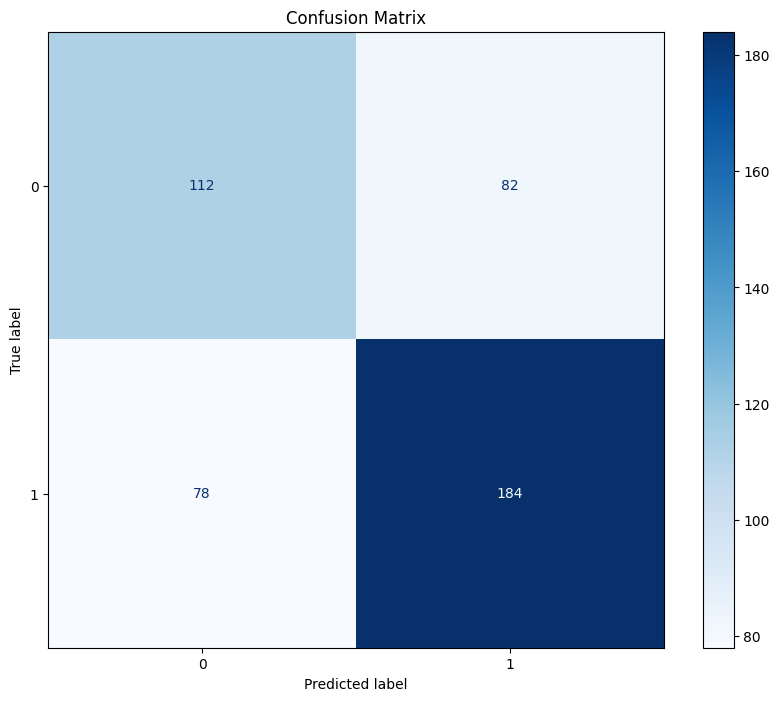

In [ ]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

In [ ]:
from sklearn.metrics import f1_score, precision_score, classification_report

# 1. יצירת תחזיות על נתוני האימות (או הבדיקה)
# המודל חוזה אם התוצאה היא 0 או 1 עבור כל שורה
y_pred = model.predict(X_val)

# 2. חישוב המדדים הספציפיים שביקשת
precision = precision_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)

# 3. הדפסה יפה של התוצאות
print(f"Precision: {precision:.4f}")
print(f"F1 Score:  {f1:.4f}")

print("-" * 30)

# בונוס: הפונקציה הזו מדפיסה דו"ח מפורט שכולל גם Precision, גם F1 וגם Recall לכל מחלקה!
print("Full Classification Report:\n")
print(classification_report(y_val, y_pred))

Precision: 0.7658
F1 Score:  0.7456
------------------------------
Full Classification Report:

              precision    recall  f1-score   support

           0       0.69      0.73      0.71        96
           1       0.77      0.73      0.75       117

    accuracy                           0.73       213
   macro avg       0.73      0.73      0.73       213
weighted avg       0.73      0.73      0.73       213



#תוצאות טובות

In [ ]:
k_days=13
test_size = 0.3
features = ["Volume","Open","High","Open_gt_Close"]
target = 'Close_gt_Open'

In [ ]:
X = pd.concat([df[features].shift(i) for i in reversed(range(k_days))], axis=1)
X.columns = [f"{feat}_t-{i}" for i in reversed(range(k_days)) for feat in features]
y = df[target]

In [ ]:
X = pd.concat([df[features].shift(i) for i in reversed(range(k_days))], axis=1)
X.columns = [f"{feat}_t-{i}" for i in reversed(range(k_days)) for feat in features]
y = df[target]

In [ ]:
X_np = X.to_numpy().astype(float)
y_np = y.to_numpy().astype(int)

In [ ]:
split_idx = int(len(X_np) * (1 - test_size))
X_train, X_test = X_np[:split_idx], X_np[split_idx:]
y_train, y_test = y_np[:split_idx], y_np[split_idx:]


In [ ]:
counter = Counter(y_train)
weight = counter[0] / counter[1]
model = xgb.XGBClassifier(
    scale_pos_weight=weight  ,
    n_estimators=450,
    max_depth=6  ,
    learning_rate=0.02,
    # use_label_encoder=False,
     eval_metric='logloss'

)
 # Adjust y_train to match X_train's shape
X_train = X_train[:,:-1]

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.02, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=450, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
import pickle

# שמירת המודל לקובץ
with open('xgb_model.pkl', 'wb') as file:
    pickle.dump(model, file)

In [ ]:
import pickle

# טעינת המודל מהקובץ
with open('xgb_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

# עכשיו אפשר להשתמש בו לחיזוי
# predictions = loaded_model.predict(X_test)

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, f1_score

# Re-create X_test from the original X_np to ensure correct number of features.
# X_np and split_idx are available from previous cells.
X_test_original_features = X_np[split_idx:]
X_test_for_prediction = X_test_original_features[:, :-1] # Slice once to get 51 features

y_pred=model.predict(X_test_for_prediction)
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1 Score:  {f1:.4f}")

Confusion Matrix:
[[111  83]
 [ 82 180]]
Accuracy: 0.6382
Precision: 0.6844
F1 Score:  0.6857


In [ ]:
eval_metric='logloss'
print (eval_metric)


logloss


In [ ]:
model.get_booster().feature_names = features

In [ ]:
k_days = 13 # מספר הימים אחורה שאת בודקת

feature_names = []

# יצירת השמות עבור המערך
for col in features:
    feature_names.append(f"{col}_current") # הערך של היום
    for i in range(1, k_days ):
        feature_names.append(f"{col}_lag_{i}") # הערכים של ימי העבר
print(feature_names)

['Volume_current', 'Volume_lag_1', 'Volume_lag_2', 'Volume_lag_3', 'Volume_lag_4', 'Volume_lag_5', 'Volume_lag_6', 'Volume_lag_7', 'Volume_lag_8', 'Volume_lag_9', 'Volume_lag_10', 'Volume_lag_11', 'Volume_lag_12', 'Open_current', 'Open_lag_1', 'Open_lag_2', 'Open_lag_3', 'Open_lag_4', 'Open_lag_5', 'Open_lag_6', 'Open_lag_7', 'Open_lag_8', 'Open_lag_9', 'Open_lag_10', 'Open_lag_11', 'Open_lag_12', 'High_current', 'High_lag_1', 'High_lag_2', 'High_lag_3', 'High_lag_4', 'High_lag_5', 'High_lag_6', 'High_lag_7', 'High_lag_8', 'High_lag_9', 'High_lag_10', 'High_lag_11', 'High_lag_12', 'Open_gt_Close_current', 'Open_gt_Close_lag_1', 'Open_gt_Close_lag_2', 'Open_gt_Close_lag_3', 'Open_gt_Close_lag_4', 'Open_gt_Close_lag_5', 'Open_gt_Close_lag_6', 'Open_gt_Close_lag_7', 'Open_gt_Close_lag_8', 'Open_gt_Close_lag_9', 'Open_gt_Close_lag_10', 'Open_gt_Close_lag_11', 'Open_gt_Close_lag_12']


51


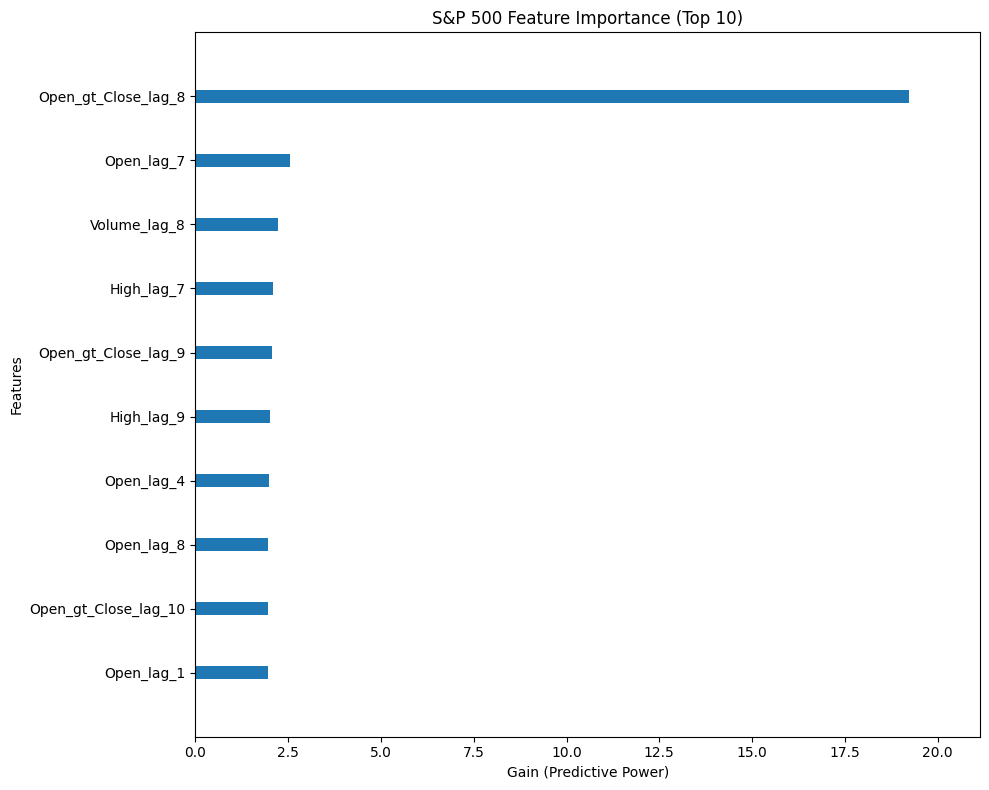

In [ ]:
corrected_feature_names = feature_names[:-1]
print (len(corrected_feature_names))
model.get_booster().feature_names = corrected_feature_names

# 2. הגדרת גודל הגרף (כדי שיהיה מקום לשמות ארוכים בצד)
plt.rcParams["figure.figsize"] = (10, 8)

# 3. יצירת גרף הבארים (Feature Importance)
# הערה: העברנו את ה-importance_type ל-'gain' כי הוא משמעותי יותר בחיזוי מניות
plot_importance(model,
                max_num_features=10, # נציג את ה-10 הכי חזקים מתוך הרשימה
                importance_type='gain',
                grid=False,
                show_values=False, # כדי שהגרף יהיה נקי
                title='S&P 500 Feature Importance (Top 10)',
                xlabel='Gain (Predictive Power)',
                ylabel='Features')

plt.tight_layout() # מבטיח שהשמות לא ייחתכו בשוליים
plt.show()


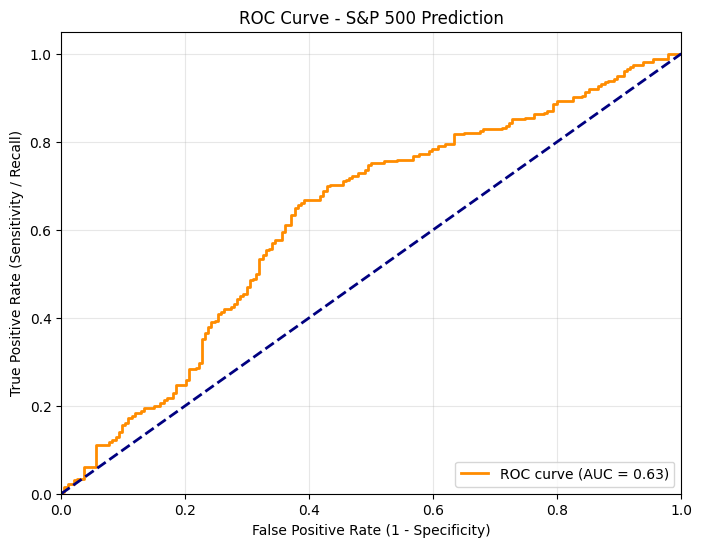

In [ ]:
X_test_for_prediction = X_test[:, :-1]
y_probs = model.predict_proba(X_test_for_prediction)[:, 1]

# 2. חישוב נתוני ה-ROC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_value = roc_auc_score(y_test, y_probs)

# 3. ציור הגרף
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_value:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # קו האלכסון (רנדומלי)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity / Recall)')
plt.title('ROC Curve - S&P 500 Prediction')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

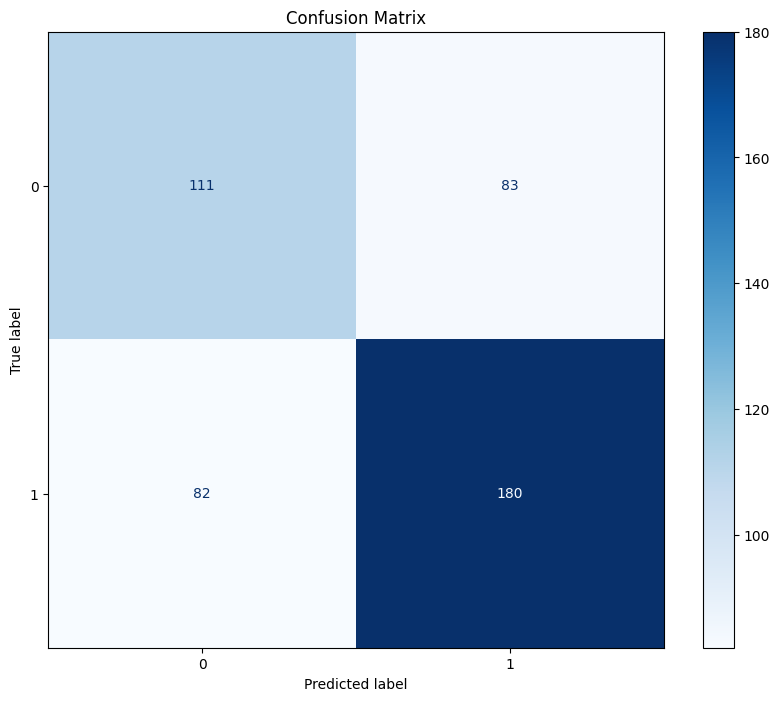

In [ ]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()
# k_days=13
# test_size = 0.3
# features = ["Volume","Open","High","Open_gt_Close"]
# target = 'Close_gt_Open'

#Deep Learning

In [42]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [81]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.1), # למניעת Overfitting
    Dense(32, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])
# optimizer = Adam(learning_rate=0.00001)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [73]:
# early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [82]:
history = model.fit(
    X_train.astype(float), y_train.astype(int),
    epochs=400,
    batch_size=32,
    validation_data=(X_val.astype(float), y_val.astype(int)),
    # callbacks=[early_stop],
    verbose=1
)

Epoch 1/400
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4824 - loss: 459318272.0000 - val_accuracy: 0.4533 - val_loss: 32790278.0000
Epoch 2/400
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5157 - loss: 32180108.0000 - val_accuracy: 0.5733 - val_loss: 524258.4062
Epoch 3/400
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5443 - loss: 5870899.5000 - val_accuracy: 0.5644 - val_loss: 0.6916
Epoch 4/400
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5462 - loss: 1177485.7500 - val_accuracy: 0.5644 - val_loss: 0.6914
Epoch 5/400
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5548 - loss: 611101.1875 - val_accuracy: 0.5644 - val_loss: 0.6910
Epoch 6/400
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5510 - loss: 305303.0625 - val_accuracy: 0.5644 - val_loss: 0.6906
Epoch 7/400
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5520 - loss: 240647.6250 - val_accuracy: 0.5644 - val_loss: 0.6902
Epoch 8/400
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accu

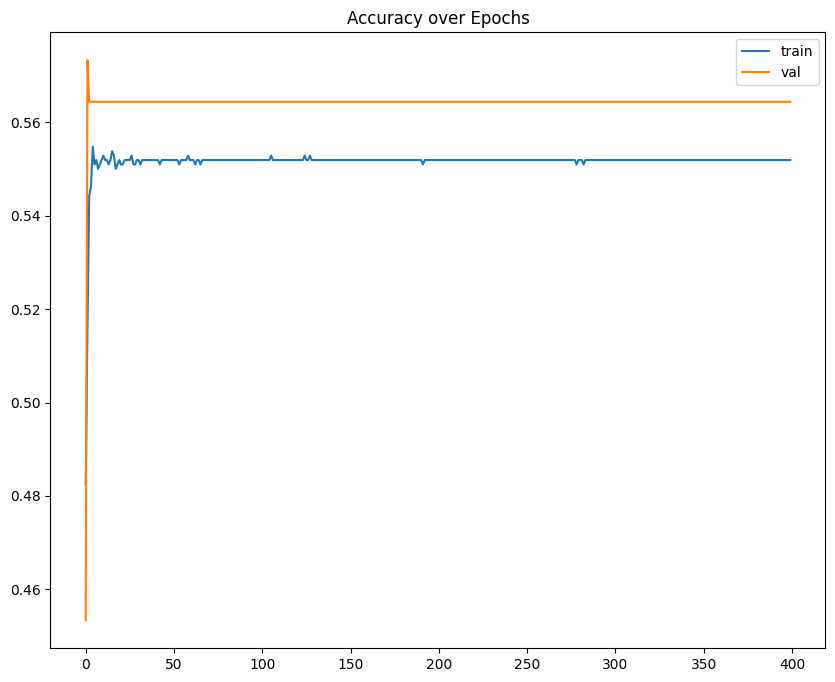

In [83]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title('Accuracy over Epochs')
plt.show()

In [84]:
y_pred = (model.predict(X_test.astype(float)) > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


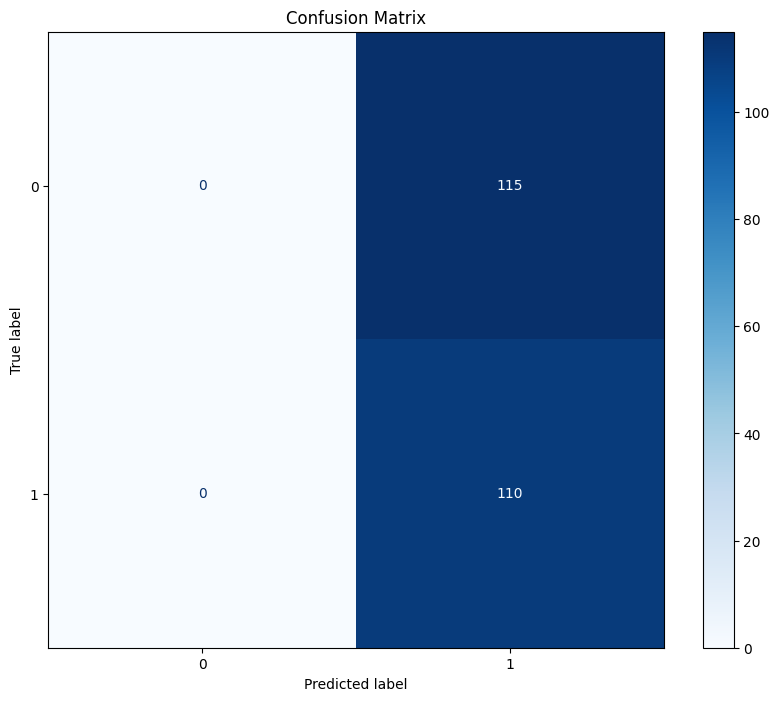

In [85]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

#save deep learning

In [ ]:
model.save('my_trained_model.h5')


#LSTM

In [27]:
# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define path and ensure the directory exists
# This assumes the folder 'lulap' is in your main 'My Drive'
folder_path = '/content/drive/MyDrive/lulap'
if not os.path.exists(folder_path):
    os.makedirs(folder_path)

# 3. Fetch S&P 500 historical data
ticker = "^GSPC"
sp500 = yf.Ticker(ticker)
hist = sp500.history(period="max")

# 4. Process data: Keep 'Close' and calculate 'Returns'
# Formula: (Price_t / Price_t-1) - 1
df = hist[['Close']].copy()
df['Returns'] = df['Close'].pct_change()
print (df.shape)
# 5. Save to CSV in the specified Drive folder
file_path = os.path.join(folder_path, 'SP500_close_returns.csv')
df.to_csv(file_path)

print(f"File successfully saved to: {file_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(24695, 2)
File successfully saved to: /content/drive/MyDrive/lulap/SP500_close_returns.csv


In [28]:
ticker = "^GSPC"
# Fetch historical data
sp500 = yf.Ticker(ticker)
hist = sp500.history(period="max")
# Save to CSV
hist.to_csv("SP500_historical_data.csv")
print("S&P 500 data saved to SP500_historical_data.csv")
print (hist.shape)

S&P 500 data saved to SP500_historical_data.csv
(24695, 7)


In [29]:
df = pd.read_csv('/content/drive/MyDrive/lulap/SP500_close_returns.csv', index_col=0)
df.dropna(inplace=True)

def prepare_data(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)

# Hyperparameters
window_size = 60 # Use last 60 days to predict the next
split = int(len(df) * 0.8)

In [30]:
# LSTM
model_path_lstm = '/content/drive/MyDrive/lulap/sp500_lstm_model.keras'
def build_model(model_type, input_shape):
    model = Sequential()
    if model_type == 'RNN':
        model.add(SimpleRNN(50, activation='tanh', input_shape=input_shape))
    elif model_type == 'LSTM':
        model.add(LSTM(50, activation='tanh', input_shape=input_shape))

    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

# Example for Close Prices
scaler_close = MinMaxScaler()
scaled_close = scaler_close.fit_transform(df[['Close']])
X_c, y_c = prepare_data(scaled_close, window_size)

# Split into Train/Test
X_train_c, X_test_c = X_c[:split], X_c[split:]
y_train_c, y_test_c = y_c[:split], y_c[split:]

# Train LSTM for Close
lstm_close = build_model('LSTM', (window_size, 1))
lstm_close.fit(X_train_c, y_train_c, epochs=10, batch_size=32, verbose=0)
lstm_close.save(model_path_lstm)
del lstm_close

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


153/153 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
Corrected Average Error: $-22.56


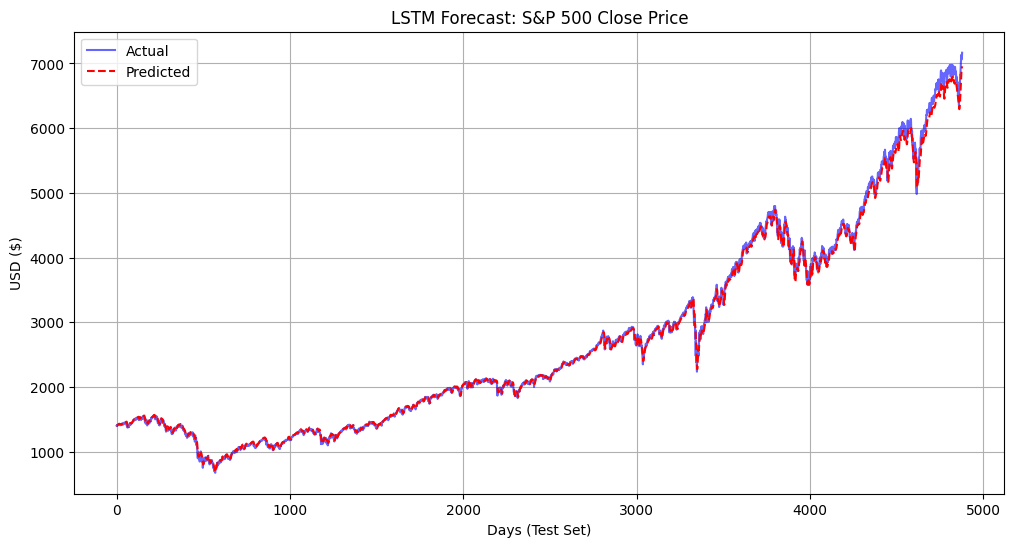

In [31]:
def plot_results(actual, predicted, title, ylabel):
    plt.figure(figsize=(12, 6))
    plt.plot(actual, label='Actual', color='blue', alpha=0.6)
    plt.plot(predicted, label='Predicted', color='red', linestyle='--')
    plt.title(title)
    plt.xlabel('Days (Test Set)')
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.show()

lstm_close = load_model(model_path_lstm)
preds_close_scaled = lstm_close.predict(X_test_c)

# Inverse transform ONCE to get USD
# We ensure y_test_c is shaped correctly (N, 1)
actual_close_usd = scaler_close.inverse_transform(y_test_c.reshape(-1, 1))
preds_close_usd = scaler_close.inverse_transform(preds_close_scaled)

# Calculate MAE (Average magnitude of error)
mae_lstm_c = mean_absolute_error(actual_close_usd, preds_close_usd)
# Calculate Bias (Actual average error: Predicted - Actual)
avg_error_lstm_c = np.mean(preds_close_usd - actual_close_usd)

print(f"Corrected Average Error: ${avg_error_lstm_c:.2f}")

# print(f"Close Price - LSTM: ${mae_lstm_c:.2f}")

plot_results(actual_close_usd, preds_close_usd, "LSTM Forecast: S&P 500 Close Price", "USD ($)")

In [32]:

# 1. Define paths for the Returns models
model_path_lstm_ret = '/content/drive/MyDrive/lulap/sp500_lstm_returns.keras'
model_path_rnn_ret = '/content/drive/MyDrive/lulap/sp500_rnn_returns.keras'

# 2. Scale the Returns data
# Note: Returns usually have outliers, so we drop NaNs first
df_ret = df[['Returns']].dropna()
scaler_ret = MinMaxScaler()
scaled_ret = scaler_ret.fit_transform(df_ret)

# 3. Prepare data sequences
X_r, y_r = prepare_data(scaled_ret, window_size)
X_train_r, X_test_r = X_r[:split], X_r[split:]
y_train_r, y_test_r = y_r[:split], y_r[split:]

# 4. Train and Save LSTM for Returns
print("Training LSTM for Returns...")
lstm_ret = build_model('LSTM', (window_size, 1))
lstm_ret.fit(X_train_r, y_train_r, epochs=10, batch_size=32, verbose=0)
lstm_ret.save(model_path_lstm_ret)
del lstm_ret

# 5. Train and Save RNN for Returns
print("Training RNN for Returns...")
rnn_ret = build_model('RNN', (window_size, 1))
rnn_ret.fit(X_train_r, y_train_r, epochs=10, batch_size=32, verbose=0)
rnn_ret.save(model_path_rnn_ret)
del rnn_ret

print("Done! Both models for Returns are saved in Drive.")

Training LSTM for Returns...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training RNN for Returns...
Done! Both models for Returns are saved in Drive.


153/153 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step
153/153 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step


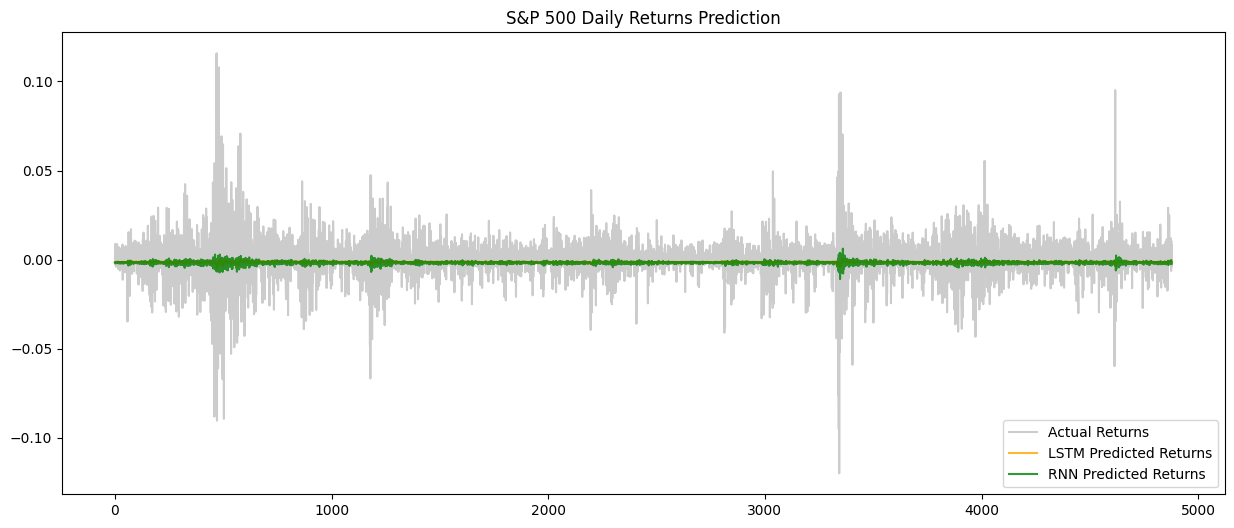

In [33]:
# Load and Predict
loaded_lstm_ret = load_model(model_path_lstm_ret)
loaded_rnn_ret = load_model(model_path_rnn_ret)

preds_lstm_r = loaded_lstm_ret.predict(X_test_r)
preds_rnn_r = loaded_rnn_ret.predict(X_test_r)

# Inverse transform to get back to actual percentage returns
actual_ret = scaler_ret.inverse_transform(y_test_r)
final_lstm_r = scaler_ret.inverse_transform(preds_lstm_r)
final_rnn_r = scaler_ret.inverse_transform(preds_rnn_r)

# Visualization
plt.figure(figsize=(15, 6))
plt.plot(actual_ret, label='Actual Returns', color='gray', alpha=0.4)
plt.plot(final_lstm_r, label='LSTM Predicted Returns', color='orange', alpha=0.8)
plt.plot(final_rnn_r, label='RNN Predicted Returns', color='green', alpha=0.8)
plt.title('S&P 500 Daily Returns Prediction')
plt.legend()
plt.show()